# Lab 6

You are tasked with evaluating card counting strategies for black jack. In order to do so, you will use object oriented programming to create a playable casino style black jack game where a computer dealer plays against $n$ computer players and possibily one human player. If you don't know the rules of blackjack or card counting, please google it. 

A few requirements:
* The game should utilize multiple 52-card decks. Typically the game is played with 6 decks.
* Players should have chips.
* Dealer's actions are predefined by rules of the game (typically hit on 16). 
* The players should be aware of all shown cards so that they can count cards.
* Each player could have a different strategy.
* The system should allow you to play large numbers of games, study the outcomes, and compare average winnings per hand rate for different strategies.

1. Begin by creating a classes to represent cards and decks. The deck should support more than one 52-card set. The deck should allow you to shuffle and draw cards. Include a "plastic" card, placed randomly in the deck. Later, when the plastic card is dealt, shuffle the cards before the next deal.

In [3]:
# I made my own simple random number generator.
class SimpleRandom:
    def __init__(self, seed):
        self.seed = seed

    def next_number(self):
        # This manually creates the next random-looking number.
        self.seed = (1103515245 * self.seed + 12345) % 2147483648
        return self.seed

    def next_int(self, limit):
        # This returns a number from 0 to limit - 1.
        if limit <= 0:
            return 0

        return self.next_number() % limit

# The Card class represents one normal card or one plastic card.
class Card:
    def __init__(self, rank, suit, is_plastic):
        self.rank = rank
        self.suit = suit
        self.is_plastic = is_plastic

    def __str__(self):
        if self.is_plastic:
            return "Plastic Card"

        return self.rank + " of " + self.suit


# The Deck class represents multiple 52-card decks together.
# It can shuffle and draw cards.
class Deck:
    def __init__(self, number_of_decks, seed):
        self.number_of_decks = number_of_decks
        self.random = SimpleRandom(seed)
        self.cards = []
        self.plastic_card_dealt = False

        self.build_deck()

    def build_deck(self):
        # I clear the old cards before rebuilding the deck.
        self.cards = []
        self.plastic_card_dealt = False

        suits = ["Hearts", "Diamonds", "Clubs", "Spades"]
        ranks = ["A", "2", "3", "4", "5", "6", "7",
                 "8", "9", "10", "J", "Q", "K"]

        # I create more than one 52-card deck.
        for deck_number in range(self.number_of_decks):
            for suit in suits:
                for rank in ranks:
                    self.cards.append(Card(rank, suit, False))

        # I shuffle the real cards first.
        self.shuffle()

        # I place one card randomly into the deck.
        plastic_position = self.random.next_int(len(self.cards))
        self.cards.insert(plastic_position, Card("Plastic", "", True))

    def shuffle(self):
        # This is a manual shuffle.
        index = len(self.cards) - 1

        while index > 0:
            random_index = self.random.next_int(index + 1)

            temp = self.cards[index]
            self.cards[index] = self.cards[random_index]
            self.cards[random_index] = temp

            index = index - 1

    def draw_card(self):
        # This draws one card from the deck.
        # If the card is drawn, I mark it and draw again.
        while True:
            if len(self.cards) == 0:
                self.build_deck()

            card = self.cards.pop()

            if card.is_plastic:
                self.plastic_card_dealt = True
            else:
                return card

    def shuffle_before_next_deal_if_needed(self):
        # This should be called before starting the next hand.
        # If the card was dealt, I rebuild and shuffle the deck.
        if self.plastic_card_dealt:
            self.build_deck()


# This only proves that the deck can be created, shuffled,
# and used to draw cards.

def main():
    deck = Deck(6, 12345)

    print("Cards in deck including plastic card:", len(deck.cards))

    print("Drawing 10 cards:")
    for count in range(10):
        card = deck.draw_card()
        print(card)

    deck.shuffle_before_next_deal_if_needed()


main()

Cards in deck including plastic card: 313
Drawing 10 cards:
2 of Diamonds
7 of Spades
A of Clubs
Q of Hearts
A of Clubs
J of Clubs
A of Clubs
K of Hearts
5 of Clubs
7 of Diamonds


2. Now design your game on a UML diagram. You may want to create classes to represent, players, a hand, and/or the game. As you work through the lab, update your UML diagram. At the end of the lab, submit your diagram (as pdf file) along with your notebook. 

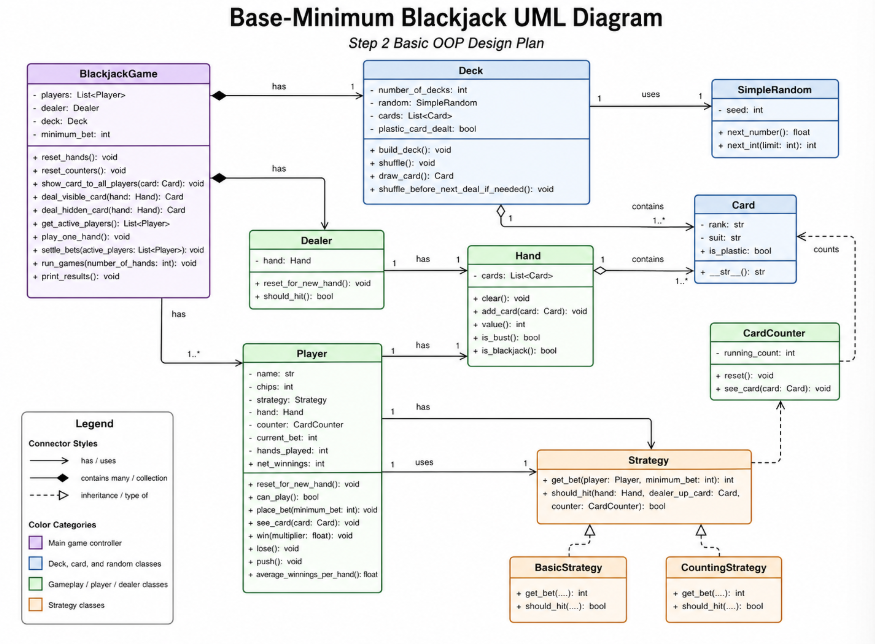

3. Begin with implementing the skeleton (ie define data members and methods/functions, but do not code the logic) of the classes in your UML diagram.

In [4]:
# I already made SimpleRandom, Card, and Deck above.
# Now I am adding the remaining classes from my UML diagram.
# I am only defining data members and method names here.

# The Hand class will store the cards for one player or the dealer.
class Hand:
    def __init__(self):
        self.cards = []

    def clear(self):
        pass

    def add_card(self, card):
        pass

    def value(self):
        pass

    def is_bust(self):
        pass

    def is_blackjack(self):
        pass


# The CardCounter class will keep track of visible cards.
class CardCounter:
    def __init__(self):
        self.running_count = 0

    def reset(self):
        pass

    def see_card(self, card):
        pass


# The BasicStrategy class will control a simple computer player.
class BasicStrategy:
    def get_bet(self, player, minimum_bet):
        pass

    def should_hit(self, hand, dealer_up_card, counter):
        pass


# The CountingStrategy class will control a player that uses card counting.
class CountingStrategy:
    def get_bet(self, player, minimum_bet):
        pass

    def should_hit(self, hand, dealer_up_card, counter):
        pass


# The Player class represents one computer player.
class Player:
    def __init__(self, name, chips, strategy):
        self.name = name
        self.chips = chips
        self.strategy = strategy
        self.hand = Hand()
        self.counter = CardCounter()
        self.current_bet = 0
        self.hands_played = 0
        self.net_winnings = 0

    def reset_for_new_hand(self):
        pass

    def can_play(self):
        pass

    def place_bet(self, minimum_bet):
        pass

    def see_card(self, card):
        pass

    def win(self, multiplier):
        pass

    def lose(self):
        pass

    def push(self):
        pass

    def average_winnings_per_hand(self):
        pass


# The Dealer class represents the computer dealer.
class Dealer:
    def __init__(self):
        self.hand = Hand()

    def reset_for_new_hand(self):
        pass

    def should_hit(self):
        pass


# The BlackjackGame class will control the full game.
class BlackjackGame:
    def __init__(self, players, number_of_decks, minimum_bet):
        self.players = players
        self.dealer = Dealer()
        self.deck = Deck(number_of_decks, 12345)
        self.minimum_bet = minimum_bet

    def reset_hands(self):
        pass

    def reset_counters(self):
        pass

    def show_card_to_all_players(self, card):
        pass

    def deal_visible_card(self, hand):
        pass

    def deal_hidden_card(self, hand):
        pass

    def get_active_players(self):
        pass

    def play_one_hand(self):
        pass

    def settle_bets(self, active_players):
        pass

    def run_games(self, number_of_hands):
        pass

    def print_results(self):
        pass

4. Complete the implementation by coding the logic of all functions. For now, just implement the dealer player and human player.

In [5]:
# The Hand class stores cards for one player or the dealer.
class Hand:
    def __init__(self):
        self.cards = []

    def clear(self):
        # I clear the hand before starting a new round.
        self.cards = []

    def add_card(self, card):
        # I add one card to the hand.
        self.cards.append(card)

    def card_value(self, card):
        # I calculate the blackjack value of one card.
        if card.rank == "A":
            return 11

        if card.rank == "J" or card.rank == "Q" or card.rank == "K":
            return 10

        return int(card.rank)

    def value(self):
        # I calculate the total value of the hand.
        total = 0
        ace_count = 0

        for card in self.cards:
            total = total + self.card_value(card)

            if card.rank == "A":
                ace_count = ace_count + 1

        # If the hand is over 21, I change aces from 11 to 1.
        while total > 21 and ace_count > 0:
            total = total - 10
            ace_count = ace_count - 1

        return total

    def is_bust(self):
        # A hand busts if it goes over 21.
        return self.value() > 21

    def is_blackjack(self):
        # Blackjack means exactly two cards with a value of 21.
        return len(self.cards) == 2 and self.value() == 21

    def show_hand(self):
        # I turn the hand into text so it can be printed.
        hand_text = ""

        for index in range(len(self.cards)):
            hand_text = hand_text + str(self.cards[index])

            if index < len(self.cards) - 1:
                hand_text = hand_text + ", "

        return hand_text


# The Dealer class represents the computer dealer.
class Dealer:
    def __init__(self):
        self.hand = Hand()

    def reset_for_new_hand(self):
        # I clear the dealer hand before each new round.
        self.hand.clear()

    def should_hit(self):
        # The dealer follows the normal rule:
        # hit below 17 and stand on 17 or higher.
        return self.hand.value() < 17

    def play_turn(self, deck):
        # The dealer keeps drawing cards while the rule says to hit.
        while self.should_hit():
            card = deck.draw_card()
            self.hand.add_card(card)


# The HumanPlayer class represents one human player.
class HumanPlayer:
    def __init__(self, name, chips):
        self.name = name
        self.chips = chips
        self.hand = Hand()
        self.current_bet = 0

    def reset_for_new_hand(self):
        # I clear the human player's hand before each new round.
        self.hand.clear()
        self.current_bet = 0

    def can_play(self):
        # The player can only play if they still have chips.
        return self.chips > 0

    def place_bet(self, minimum_bet):
        # I ask the player for a bet.
        print()
        print(self.name, "has", self.chips, "chips.")
        bet = int(input("Enter your bet: "))

        # The bet cannot be below the minimum bet.
        if bet < minimum_bet:
            bet = minimum_bet

        # The player cannot bet more chips than they have.
        if bet > self.chips:
            bet = self.chips

        self.chips = self.chips - bet
        self.current_bet = bet

    def play_turn(self, deck, dealer_up_card):
        # The human player chooses hit or stand.
        done = False

        while not done and not self.hand.is_bust():
            print()
            print("Dealer shows:", dealer_up_card)
            print(self.name + "'s hand:", self.hand.show_hand())
            print("Hand value:", self.hand.value())

            choice = input("Hit or stand? Enter h or s: ")

            if choice == "h" or choice == "H":
                card = deck.draw_card()
                self.hand.add_card(card)
                print("You drew:", card)
            else:
                done = True

    def win(self):
        # A normal win gives the bet back plus the same amount as profit.
        self.chips = self.chips + self.current_bet * 2
        self.current_bet = 0

    def lose(self):
        # The bet was already removed, so I only reset the current bet.
        self.current_bet = 0

    def push(self):
        # A push means the player gets the original bet back.
        self.chips = self.chips + self.current_bet
        self.current_bet = 0


# The Game class controls one simple human-vs-dealer blackjack game.
class Game:
    def __init__(self):
        self.deck = Deck(6, 12345)
        self.dealer = Dealer()
        self.player = HumanPlayer("Human Player", 100)
        self.minimum_bet = 10

    def reset_for_new_hand(self):
        # If the plastic card was dealt, I reshuffle before the next hand.
        self.deck.shuffle_before_next_deal_if_needed()

        self.dealer.reset_for_new_hand()
        self.player.reset_for_new_hand()

    def deal_starting_cards(self):
        # I deal two cards to the player and two cards to the dealer.
        self.player.hand.add_card(self.deck.draw_card())
        self.dealer.hand.add_card(self.deck.draw_card())

        self.player.hand.add_card(self.deck.draw_card())
        self.dealer.hand.add_card(self.deck.draw_card())

    def settle_result(self):
        # I compare the player hand and dealer hand to decide the result.
        player_value = self.player.hand.value()
        dealer_value = self.dealer.hand.value()

        print()
        print("Final hands:")
        print(self.player.name + ":", self.player.hand.show_hand(), "=", player_value)
        print("Dealer:", self.dealer.hand.show_hand(), "=", dealer_value)

        if self.player.hand.is_bust():
            print("Player busts. Dealer wins.")
            self.player.lose()

        elif self.dealer.hand.is_bust():
            print("Dealer busts. Player wins.")
            self.player.win()

        elif player_value > dealer_value:
            print("Player wins.")
            self.player.win()

        elif player_value < dealer_value:
            print("Dealer wins.")
            self.player.lose()

        else:
            print("Push. It is a tie.")
            self.player.push()

    def play_one_hand(self):
        # I play one full hand between the human player and dealer.
        self.reset_for_new_hand()

        if not self.player.can_play():
            print("The player has no chips left.")
            return

        self.player.place_bet(self.minimum_bet)
        self.deal_starting_cards()

        dealer_up_card = self.dealer.hand.cards[0]

        self.player.play_turn(self.deck, dealer_up_card)

        if not self.player.hand.is_bust():
            self.dealer.play_turn(self.deck)

        self.settle_result()

        print("Player chips:", self.player.chips)


5.  Test. Demonstrate game play. For example, create a game of several dealer players and show that the game is functional through several rounds.

In [7]:
class DealerPlayer:
    def __init__(self, name, chips):
        self.name = name
        self.chips = chips
        self.hand = Hand()
        self.current_bet = 0

    def reset_for_new_hand(self):
        # I clear this player's hand before each new round.
        self.hand.clear()
        self.current_bet = 0

    def can_play(self):
        # The player can only play if they still have chips.
        return self.chips > 0

    def place_bet(self, minimum_bet):
        # This test player always bets the minimum.
        bet = minimum_bet

        if bet > self.chips:
            bet = self.chips

        self.chips = self.chips - bet
        self.current_bet = bet

    def should_hit(self):
        # This player follows the same rule as the dealer.
        return self.hand.value() < 17

    def play_turn(self, deck):
        # The player keeps drawing until reaching 17 or higher.
        while self.should_hit():
            card = deck.draw_card()
            self.hand.add_card(card)

    def win(self):
        # A win gives back the bet plus the same amount as profit.
        self.chips = self.chips + self.current_bet * 2
        self.current_bet = 0

    def lose(self):
        # The bet was already removed from chips.
        self.current_bet = 0

    def push(self):
        # A push gives the original bet back.
        self.chips = self.chips + self.current_bet
        self.current_bet = 0


class MultiPlayerTestGame:
    def __init__(self):
        self.deck = Deck(6, 12345)
        self.dealer = Dealer()
        self.minimum_bet = 10

        self.players = [
            DealerPlayer("Player 1", 100),
            DealerPlayer("Player 2", 100),
            DealerPlayer("Player 3", 100)
        ]

    def reset_for_new_round(self):
        # If the plastic card was dealt, I shuffle before the next round.
        self.deck.shuffle_before_next_deal_if_needed()

        self.dealer.reset_for_new_hand()

        for player in self.players:
            player.reset_for_new_hand()

    def deal_starting_cards(self):
        # I deal two cards to each player and two cards to the dealer.
        for player in self.players:
            if player.can_play():
                player.hand.add_card(self.deck.draw_card())

        self.dealer.hand.add_card(self.deck.draw_card())

        for player in self.players:
            if player.can_play():
                player.hand.add_card(self.deck.draw_card())

        self.dealer.hand.add_card(self.deck.draw_card())

    def play_players(self):
        # Each player plays using the dealer-style rule.
        for player in self.players:
            if player.can_play():
                player.play_turn(self.deck)

    def all_players_busted(self):
        # If every player busted, the dealer does not need to draw.
        for player in self.players:
            if player.can_play() and not player.hand.is_bust():
                return False

        return True

    def settle_player(self, player):
        # I compare one player against the dealer.
        player_value = player.hand.value()
        dealer_value = self.dealer.hand.value()

        if player.hand.is_bust():
            player.lose()
            return "lost by busting"

        if self.dealer.hand.is_bust():
            player.win()
            return "won because dealer busted"

        if player_value > dealer_value:
            player.win()
            return "won"

        if player_value < dealer_value:
            player.lose()
            return "lost"

        player.push()
        return "pushed"

    def play_one_round(self, round_number):
        print()
        print("Round", round_number)

        self.reset_for_new_round()

        for player in self.players:
            if player.can_play():
                player.place_bet(self.minimum_bet)

        self.deal_starting_cards()
        self.play_players()

        if not self.all_players_busted():
            self.dealer.play_turn(self.deck)

        print("Dealer:", self.dealer.hand.show_hand(), "=", self.dealer.hand.value())

        for player in self.players:
            if player.current_bet > 0 or player.can_play():
                result = self.settle_player(player)

                print(player.name + ":", player.hand.show_hand(), "=", player.hand.value())
                print(player.name, result)
                print(player.name, "chips:", player.chips)
                print()

    def play_several_rounds(self, number_of_rounds):
        # I run several rounds to show that the game works.
        for round_number in range(1, number_of_rounds + 1):
            self.play_one_round(round_number)


# testing :)
test_game = MultiPlayerTestGame()
test_game.play_several_rounds(5)


Round 1
Dealer: Q of Hearts, K of Hearts = 20
Player 1: 2 of Diamonds, A of Clubs, 5 of Clubs = 18
Player 1 lost
Player 1 chips: 90

Player 2: 7 of Spades, J of Clubs = 17
Player 2 lost
Player 2 chips: 90

Player 3: A of Clubs, A of Clubs, 7 of Diamonds = 19
Player 3 lost
Player 3 chips: 90


Round 2
Dealer: 7 of Spades, Q of Hearts = 17
Player 1: Q of Spades, J of Clubs = 20
Player 1 won
Player 1 chips: 100

Player 2: 8 of Diamonds, 6 of Spades, 9 of Clubs = 23
Player 2 lost by busting
Player 2 chips: 80

Player 3: 5 of Clubs, 8 of Spades, 3 of Hearts, 6 of Diamonds = 22
Player 3 lost by busting
Player 3 chips: 80


Round 3
Dealer: J of Hearts, 10 of Diamonds = 20
Player 1: 8 of Hearts, J of Clubs = 18
Player 1 lost
Player 1 chips: 90

Player 2: 9 of Clubs, 8 of Clubs = 17
Player 2 lost
Player 2 chips: 70

Player 3: 9 of Spades, 10 of Hearts = 19
Player 3 lost
Player 3 chips: 70


Round 4
Dealer: 7 of Hearts, 3 of Clubs, 4 of Spades, K of Diamonds = 24
Player 1: 8 of Hearts, 5 of Hea

6. Implement a new player with the following strategy:

    * Assign each card a value: 
        * Cards 2 to 6 are +1 
        * Cards 7 to 9 are 0 
        * Cards 10 through Ace are -1
    * Compute the sum of the values for all cards seen so far.
    * Hit if sum is very negative, stay if sum is very positive. Select a threshold for hit/stay, e.g. 0 or -2.  

In [9]:
# Step 6: New card-counting player
# I am not repeating the old Deck, Hand, Dealer, or DealerPlayer classes.
# This new player uses the cards it has seen to decide whether to hit or stay.


class CountingDealerPlayer(DealerPlayer):
    def __init__(self, name, chips, threshold):
        # I reuse the dealer-style player setup.
        DealerPlayer.__init__(self, name, chips)

        # I keep the running count of all visible cards seen so far.
        self.running_count = 0

        # I chose -2 as my threshold.
        # If the count is very negative, the player is more willing to hit.
        # If the count is higher than this, the player is more willing to stay.
        self.threshold = threshold

    def reset_count(self):
        # I reset the count when the deck is shuffled.
        self.running_count = 0

    def count_card_value(self, card):
        # Cards 2 through 6 count as +1.
        if card.rank == "2" or card.rank == "3" or card.rank == "4" or card.rank == "5" or card.rank == "6":
            return 1

        # Cards 10, J, Q, K, and A count as -1.
        if card.rank == "10" or card.rank == "J" or card.rank == "Q" or card.rank == "K" or card.rank == "A":
            return -1

        # Cards 7, 8, and 9 count as 0.
        return 0

    def see_card(self, card):
        # Every time this player sees a card, I update the running count.
        self.running_count = self.running_count + self.count_card_value(card)

    def should_hit(self):
        # I still use basic safety rules first.
        # If the hand is below 12, I hit because busting is not likely.
        if self.hand.value() < 12:
            return True

        # If the hand is 17 or more, I stay.
        if self.hand.value() >= 17:
            return False

        # For hands from 12 to 16, I use the card count.
        # If the count is very negative, I hit.
        # If the count is positive enough, I stay.
        return self.running_count <= self.threshold

    def play_turn(self, deck):
        # The counting player draws while the strategy says to hit.
        while self.should_hit():
            card = deck.draw_card()
            self.hand.add_card(card)

            # The card drawn by the player is visible, so I count it.
            self.see_card(card)


# Step 6 small test
# This test only shows that the new counting player works.
def test_counting_player():
    deck = Deck(6, 12345)

    regular_player = DealerPlayer("Regular Player", 100)
    counting_player = CountingDealerPlayer("Counting Player", 100, -2)

    players = [regular_player, counting_player]

    dealer = Dealer()
    minimum_bet = 10

    for round_number in range(1, 4):
        print()
        print("Step 6 Round", round_number)

        # If the plastic card was dealt, I reshuffle and reset the count.
        if deck.plastic_card_dealt:
            deck.shuffle_before_next_deal_if_needed()
            counting_player.reset_count()

        dealer.reset_for_new_hand()

        for player in players:
            player.reset_for_new_hand()
            player.place_bet(minimum_bet)

        # I deal two cards to each player.
        for player in players:
            card = deck.draw_card()
            player.hand.add_card(card)
            counting_player.see_card(card)

        dealer.hand.add_card(deck.draw_card())
        counting_player.see_card(dealer.hand.cards[0])

        for player in players:
            card = deck.draw_card()
            player.hand.add_card(card)
            counting_player.see_card(card)

        # Dealer second card is hidden at first, so I do not count it yet.
        hidden_dealer_card = deck.draw_card()
        dealer.hand.add_card(hidden_dealer_card)

        # Players take their turns.
        for player in players:
            player.play_turn(deck)

        # Now the dealer's hidden card is revealed, so I count it.
        counting_player.see_card(hidden_dealer_card)

        dealer.play_turn(deck)

        print("Dealer:", dealer.hand.show_hand(), "=", dealer.hand.value())

        for player in players:
            print(player.name + ":", player.hand.show_hand(), "=", player.hand.value())

        print("Counting Player running count:", counting_player.running_count)


test_counting_player()


Step 6 Round 1
Dealer: A of Clubs, J of Clubs = 21
Regular Player: 2 of Diamonds, Q of Hearts, A of Clubs, K of Hearts = 23
Counting Player: 7 of Spades, A of Clubs = 18
Counting Player running count: -3

Step 6 Round 2
Dealer: Q of Spades, 7 of Spades = 17
Regular Player: 5 of Clubs, 8 of Diamonds, J of Clubs = 23
Counting Player: 7 of Diamonds, 5 of Clubs, 6 of Spades = 18
Counting Player running count: -1

Step 6 Round 3
Dealer: 9 of Clubs, 8 of Hearts = 17
Regular Player: 8 of Spades, 3 of Hearts, 9 of Clubs = 20
Counting Player: Q of Hearts, 6 of Diamonds = 16
Counting Player running count: 0


7. Create a test scenario where one player, using the above strategy, is playing with a dealer and 3 other players that follow the dealer's strategy. Each player starts with same number of chips. Play 50 rounds (or until the strategy player is out of money). Compute the strategy player's winnings. You may remove unnecessary printouts from your code (perhaps implement a verbose/quiet mode) to reduce the output.

In [11]:
class StrategyTestGame:
    def __init__(self, starting_chips, minimum_bet, number_of_rounds, verbose):
        self.starting_chips = starting_chips
        self.minimum_bet = minimum_bet
        self.number_of_rounds = number_of_rounds
        self.verbose = verbose

        self.deck = Deck(6, 12345)
        self.dealer = Dealer()

        # This is the strategy player from Step 6.
        self.strategy_player = CountingDealerPlayer("Counting Strategy Player", starting_chips, -2)

        # These three players follow the dealer strategy.
        self.players = [
            self.strategy_player,
            DealerPlayer("Dealer Strategy Player 1", starting_chips),
            DealerPlayer("Dealer Strategy Player 2", starting_chips),
            DealerPlayer("Dealer Strategy Player 3", starting_chips)
        ]

    def reset_for_new_round(self):
        # If the plastic card was dealt, I shuffle before the next round.
        # I also reset the counting player's running count.
        if self.deck.plastic_card_dealt:
            self.deck.shuffle_before_next_deal_if_needed()
            self.strategy_player.reset_count()

        self.dealer.reset_for_new_hand()

        for player in self.players:
            player.reset_for_new_hand()

    def active_players(self):
        # I only keep players who still have chips.
        active = []

        for player in self.players:
            if player.can_play():
                active.append(player)

        return active

    def deal_visible_card(self, hand):
        # This card is visible, so the counting player counts it.
        card = self.deck.draw_card()
        hand.add_card(card)
        self.strategy_player.see_card(card)
        return card

    def deal_hidden_card(self, hand):
        # This card is hidden at first, so the counting player does not count it yet.
        card = self.deck.draw_card()
        hand.add_card(card)
        return card

    def place_bets(self, active):
        # Every active player places the minimum bet.
        for player in active:
            player.place_bet(self.minimum_bet)

    def deal_starting_cards(self, active):
        # First card to every player.
        for player in active:
            self.deal_visible_card(player.hand)

        # Dealer's first card is visible.
        self.deal_visible_card(self.dealer.hand)

        # Second card to every player.
        for player in active:
            self.deal_visible_card(player.hand)

        # Dealer's second card is hidden at first.
        hidden_card = self.deal_hidden_card(self.dealer.hand)

        return hidden_card

    def play_one_player(self, player):
        # I let one player draw cards until their strategy says to stop.
        while not player.hand.is_bust() and player.should_hit():
            self.deal_visible_card(player.hand)

    def play_all_players(self, active):
        # Each player takes a turn.
        for player in active:
            self.play_one_player(player)

    def all_players_busted(self, active):
        # If all players bust, the dealer does not need to play.
        for player in active:
            if not player.hand.is_bust():
                return False

        return True

    def play_dealer(self):
        # The dealer hits below 17.
        while self.dealer.should_hit():
            self.deal_visible_card(self.dealer.hand)

    def settle_one_player(self, player):
        # I compare one player against the dealer and update chips.
        player_value = player.hand.value()
        dealer_value = self.dealer.hand.value()

        if player.hand.is_bust():
            player.lose()
            return "lost by busting"

        if self.dealer.hand.is_bust():
            player.win()
            return "won because dealer busted"

        if player_value > dealer_value:
            player.win()
            return "won"

        if player_value < dealer_value:
            player.lose()
            return "lost"

        player.push()
        return "pushed"

    def settle_all_players(self, active):
        # I settle the result for each player.
        for player in active:
            result = self.settle_one_player(player)

            if self.verbose:
                print(player.name + ":", player.hand.show_hand(), "=", player.hand.value())
                print(player.name, result)
                print(player.name, "chips:", player.chips)
                print()

    def play_one_round(self, round_number):
        self.reset_for_new_round()

        active = self.active_players()

        if len(active) == 0:
            return

        self.place_bets(active)

        hidden_dealer_card = self.deal_starting_cards(active)

        self.play_all_players(active)

        # Now the hidden dealer card is revealed, so the counting player counts it.
        self.strategy_player.see_card(hidden_dealer_card)

        if not self.all_players_busted(active):
            self.play_dealer()

        if self.verbose:
            print()
            print("Round", round_number)
            print("Dealer:", self.dealer.hand.show_hand(), "=", self.dealer.hand.value())
            print("Counting player's running count:", self.strategy_player.running_count)
            print()

        self.settle_all_players(active)

    def run_test(self):
        round_number = 1

        # I play 50 rounds or stop early if the strategy player is out of money.
        while round_number <= self.number_of_rounds and self.strategy_player.can_play():
            self.play_one_round(round_number)
            round_number = round_number + 1

        winnings = self.strategy_player.chips - self.starting_chips

        print("Step 7 Results")
        print("Rounds attempted:", self.number_of_rounds)
        print("Rounds completed:", round_number - 1)
        print("Strategy player starting chips:", self.starting_chips)
        print("Strategy player final chips:", self.strategy_player.chips)
        print("Strategy player winnings:", winnings)


# I set verbose to False so the output is not too long.
test_game = StrategyTestGame(
    starting_chips=100,
    minimum_bet=10,
    number_of_rounds=50,
    verbose=False
)

test_game.run_test()

Step 7 Results
Rounds attempted: 50
Rounds completed: 50
Strategy player starting chips: 100
Strategy player final chips: 70
Strategy player winnings: -30


8. Create a loop that runs 100 games of 50 rounds, as setup in previous question, and store the strategy player's chips at the end of the game (aka "winnings") in a list. Histogram the winnings. What is the average winnings per round? What is the standard deviation. What is the probabilty of net winning or lossing after 50 rounds?


Number of games: 100
Rounds per game: 50

Ending chips list:
[70, 80, 70, 70, 0, 0, 0, 30, 50, 130, 0, 0, 50, 0, 210, 0, 100, 230, 50, 0, 80, 100, 80, 10, 70, 0, 190, 0, 100, 0, 50, 0, 120, 90, 40, 0, 60, 60, 0, 30, 0, 0, 150, 50, 0, 50, 150, 0, 160, 0, 0, 100, 0, 0, 0, 80, 110, 40, 60, 40, 0, 180, 90, 30, 90, 0, 70, 80, 50, 0, 90, 100, 20, 0, 100, 190, 60, 60, 0, 190, 60, 190, 180, 50, 90, 50, 110, 180, 60, 50, 100, 0, 150, 110, 70, 0, 100, 60, 100, 0]

Net winnings list:
[-30, -20, -30, -30, -100, -100, -100, -70, -50, 30, -100, -100, -50, -100, 110, -100, 0, 130, -50, -100, -20, 0, -20, -90, -30, -100, 90, -100, 0, -100, -50, -100, 20, -10, -60, -100, -40, -40, -100, -70, -100, -100, 50, -50, -100, -50, 50, -100, 60, -100, -100, 0, -100, -100, -100, -20, 10, -60, -40, -60, -100, 80, -10, -70, -10, -100, -30, -20, -50, -100, -10, 0, -80, -100, 0, 90, -40, -40, -100, 90, -40, 90, 80, -50, -10, -50, 10, 80, -40, -50, 0, -100, 50, 10, -30, -100, 0, -40, 0, -100]

Average net winnings pe

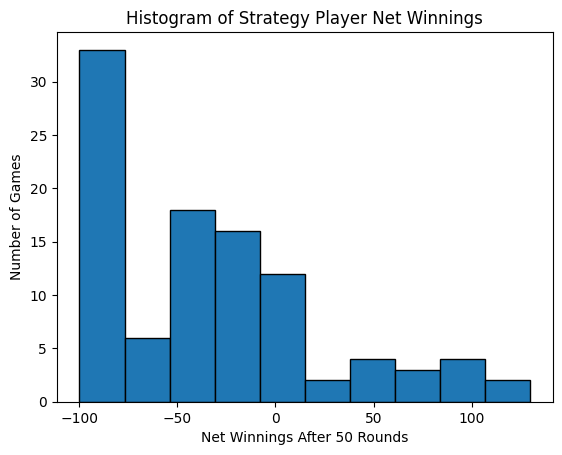

In [15]:
# I am using matplotlib only for the histogram.
import matplotlib.pyplot as plt


def run_one_quiet_game(game_number):
    # I create one game using the same setup from Step 7.
    game = StrategyTestGame(
        starting_chips=100,
        minimum_bet=10,
        number_of_rounds=50,
        verbose=False
    )

    # I change the seed each game so all 100 games are not identical.
    game.deck = Deck(6, 12345 + game_number)

    round_number = 1

    # I play 50 rounds or stop early if the strategy player runs out of chips.
    while round_number <= game.number_of_rounds and game.strategy_player.can_play():
        game.play_one_round(round_number)
        round_number = round_number + 1

    ending_chips = game.strategy_player.chips
    net_winnings = ending_chips - game.starting_chips

    return ending_chips, net_winnings


def average(numbers):
    total = 0

    for number in numbers:
        total = total + number

    return total / len(numbers)


def standard_deviation(numbers):
    avg = average(numbers)
    total = 0

    for number in numbers:
        difference = number - avg
        total = total + difference * difference

    variance = total / len(numbers)

    return variance ** 0.5


# I store the strategy player's ending chips and net winnings.
ending_chips_list = []
net_winnings_list = []

number_of_games = 100
rounds_per_game = 50

for game_number in range(number_of_games):
    ending_chips, net_winnings = run_one_quiet_game(game_number)

    ending_chips_list.append(ending_chips)
    net_winnings_list.append(net_winnings)


# I calculate the statistics.
average_net_winnings_per_game = average(net_winnings_list)
average_winnings_per_round = average_net_winnings_per_game / rounds_per_game
standard_deviation_net_winnings = standard_deviation(net_winnings_list)

winning_games = 0
losing_games = 0
break_even_games = 0

for winnings in net_winnings_list:
    if winnings > 0:
        winning_games = winning_games + 1
    elif winnings < 0:
        losing_games = losing_games + 1
    else:
        break_even_games = break_even_games + 1

probability_net_winning = winning_games / number_of_games
probability_net_losing = losing_games / number_of_games
probability_break_even = break_even_games / number_of_games


# I print the results.
print("Number of games:", number_of_games)
print("Rounds per game:", rounds_per_game)

print()
print("Ending chips list:")
print(ending_chips_list)

print()
print("Net winnings list:")
print(net_winnings_list)

print()
print("Average net winnings per game:", average_net_winnings_per_game)
print("Average winnings per round:", average_winnings_per_round)
print("Standard deviation of net winnings:", standard_deviation_net_winnings)

print()
print("Probability of net winning after 50 rounds:", probability_net_winning)
print("Probability of net losing after 50 rounds:", probability_net_losing)
print("Probability of breaking even after 50 rounds:", probability_break_even)


# I create a histogram of the net winnings.
plt.hist(net_winnings_list, bins=10, edgecolor="black")
plt.title("Histogram of Strategy Player Net Winnings")
plt.xlabel("Net Winnings After 50 Rounds")
plt.ylabel("Number of Games")
plt.show()

9. Repeat previous questions scanning the value of the threshold. Try at least 5 different threshold values. Can you find an optimal value?

Step 9 Results
Threshold: -6
Average winnings per round: -0.93
Standard deviation: 57.55649398634354
Probability of net winning: 0.16
Probability of net losing: 0.8
Probability of breaking even: 0.04

Threshold: -4
Average winnings per round: -0.858
Standard deviation: 63.234405192110366
Probability of net winning: 0.26
Probability of net losing: 0.72
Probability of breaking even: 0.02

Threshold: -2
Average winnings per round: -0.736
Standard deviation: 59.46225693664844
Probability of net winning: 0.18
Probability of net losing: 0.73
Probability of breaking even: 0.09

Threshold: 0
Average winnings per round: -0.828
Standard deviation: 52.01961168636305
Probability of net winning: 0.21
Probability of net losing: 0.73
Probability of breaking even: 0.06

Threshold: 2
Average winnings per round: -0.654
Standard deviation: 50.3756885809018
Probability of net winning: 0.24
Probability of net losing: 0.71
Probability of breaking even: 0.05

Best threshold found: 2
Best average winnings per

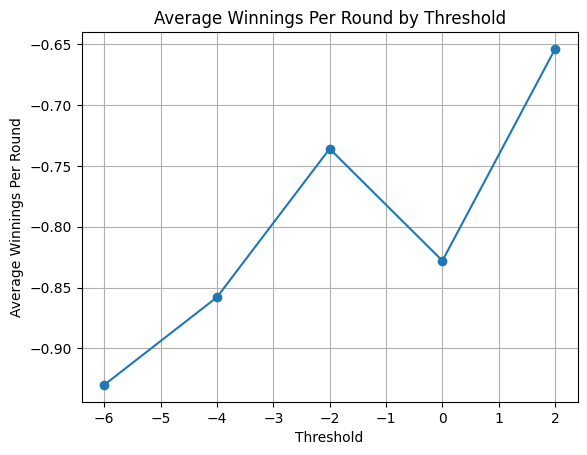

In [17]:
# Step 9: Scan different threshold values.
# I am testing at least 5 thresholds to see which one gives the best result.

import matplotlib.pyplot as plt


def run_one_threshold_game(game_number, threshold):
    # I create the same game setup from Step 7.
    game = StrategyTestGame(
        starting_chips=100,
        minimum_bet=10,
        number_of_rounds=50,
        verbose=False
    )

    # I change the counting player's threshold.
    game.strategy_player.threshold = threshold

    # I use a different seed so each game is not identical.
    game.deck = Deck(6, 12345 + game_number)

    round_number = 1

    # I play 50 rounds or stop if the strategy player runs out of chips.
    while round_number <= game.number_of_rounds and game.strategy_player.can_play():
        game.play_one_round(round_number)
        round_number = round_number + 1

    net_winnings = game.strategy_player.chips - game.starting_chips

    return net_winnings


def test_one_threshold(threshold, number_of_games, rounds_per_game):
    # I store the winnings for this threshold.
    winnings_list = []

    for game_number in range(number_of_games):
        winnings = run_one_threshold_game(game_number, threshold)
        winnings_list.append(winnings)

    avg_winnings_per_game = average(winnings_list)
    avg_winnings_per_round = avg_winnings_per_game / rounds_per_game
    sd = standard_deviation(winnings_list)

    winning_games = 0
    losing_games = 0
    break_even_games = 0

    for winnings in winnings_list:
        if winnings > 0:
            winning_games = winning_games + 1
        elif winnings < 0:
            losing_games = losing_games + 1
        else:
            break_even_games = break_even_games + 1

    probability_win = winning_games / number_of_games
    probability_loss = losing_games / number_of_games
    probability_break_even = break_even_games / number_of_games

    return avg_winnings_per_round, sd, probability_win, probability_loss, probability_break_even


# I am testing at least 5 different threshold values.
thresholds = [-6, -4, -2, 0, 2]

number_of_games = 100
rounds_per_game = 50

average_results = []
sd_results = []
win_probability_results = []
loss_probability_results = []
break_even_probability_results = []

best_threshold = thresholds[0]
best_average = None

print("Step 9 Results")

for threshold in thresholds:
    avg_per_round, sd, prob_win, prob_loss, prob_even = test_one_threshold(
        threshold,
        number_of_games,
        rounds_per_game
    )

    average_results.append(avg_per_round)
    sd_results.append(sd)
    win_probability_results.append(prob_win)
    loss_probability_results.append(prob_loss)
    break_even_probability_results.append(prob_even)

    print("Threshold:", threshold)
    print("Average winnings per round:", avg_per_round)
    print("Standard deviation:", sd)
    print("Probability of net winning:", prob_win)
    print("Probability of net losing:", prob_loss)
    print("Probability of breaking even:", prob_even)
    print()

    if best_average is None or avg_per_round > best_average:
        best_average = avg_per_round
        best_threshold = threshold


print("Best threshold found:", best_threshold)
print("Best average winnings per round:", best_average)


# I make a simple plot to compare the thresholds.
plt.plot(thresholds, average_results, marker="o")
plt.title("Average Winnings Per Round by Threshold")
plt.xlabel("Threshold")
plt.ylabel("Average Winnings Per Round")
plt.grid(True)
plt.show()

10. Create a new strategy based on web searches or your own ideas. Demonstrate that the new strategy will result in increased or decreased winnings. 

Old strategy average winnings per round: -0.7659999999999999
New strategy average winnings per round: -0.654
Difference: 0.11199999999999988

Old strategy standard deviation: 59.66665735567905
New strategy standard deviation: 121.47308343826636

The new strategy increased the average winnings per round.


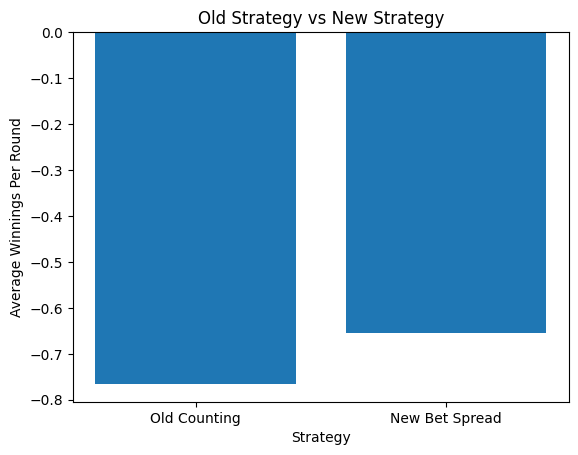

In [18]:
# Step 10: Create a new strategy and compare it to the old counting strategy.
# I am not repeating the old code.
# This new strategy uses the card count for both hit/stay decisions and bet size.


class BetSpreadCountingPlayer(CountingDealerPlayer):
    def place_bet(self, minimum_bet):
        # My new idea is to bet more when the count is positive.
        # A positive count means more high cards may be left in the deck.
        bet = minimum_bet

        if self.running_count >= 4:
            bet = minimum_bet * 5
        elif self.running_count >= 2:
            bet = minimum_bet * 3

        # The player cannot bet more chips than they have.
        if bet > self.chips:
            bet = self.chips

        self.chips = self.chips - bet
        self.current_bet = bet

    def should_hit(self):
        # I still use simple safety rules first.
        if self.hand.value() < 12:
            return True

        if self.hand.value() >= 17:
            return False

        # For hands from 12 to 16, I use the running count.
        # If the count is low, I hit.
        # If the count is high, I stay.
        return self.running_count <= self.threshold


class BetSpreadStrategyTestGame(StrategyTestGame):
    def __init__(self, starting_chips, minimum_bet, number_of_rounds, verbose):
        # I reuse the Step 7 game setup first.
        StrategyTestGame.__init__(self, starting_chips, minimum_bet, number_of_rounds, verbose)

        # Then I replace the old strategy player with my new strategy player.
        self.strategy_player = BetSpreadCountingPlayer("Bet Spread Counting Player", starting_chips, -2)

        self.players[0] = self.strategy_player


def run_comparison_game(game_class, game_number):
    # I run one quiet game for whichever strategy class is passed in.
    game = game_class(
        starting_chips=100,
        minimum_bet=10,
        number_of_rounds=50,
        verbose=False
    )

    # I use the same seed pattern so the comparison is fair.
    game.deck = Deck(6, 50000 + game_number)

    round_number = 1

    while round_number <= game.number_of_rounds and game.strategy_player.can_play():
        game.play_one_round(round_number)
        round_number = round_number + 1

    net_winnings = game.strategy_player.chips - game.starting_chips

    return net_winnings


old_strategy_winnings = []
new_strategy_winnings = []

number_of_games = 100
rounds_per_game = 50

for game_number in range(number_of_games):
    old_result = run_comparison_game(StrategyTestGame, game_number)
    new_result = run_comparison_game(BetSpreadStrategyTestGame, game_number)

    old_strategy_winnings.append(old_result)
    new_strategy_winnings.append(new_result)


old_average_per_game = average(old_strategy_winnings)
new_average_per_game = average(new_strategy_winnings)

old_average_per_round = old_average_per_game / rounds_per_game
new_average_per_round = new_average_per_game / rounds_per_game

old_sd = standard_deviation(old_strategy_winnings)
new_sd = standard_deviation(new_strategy_winnings)

difference = new_average_per_round - old_average_per_round

print("Old strategy average winnings per round:", old_average_per_round)
print("New strategy average winnings per round:", new_average_per_round)
print("Difference:", difference)

print()
print("Old strategy standard deviation:", old_sd)
print("New strategy standard deviation:", new_sd)

print()
if difference > 0:
    print("The new strategy increased the average winnings per round.")
elif difference < 0:
    print("The new strategy decreased the average winnings per round.")
else:
    print("The new strategy had the same average winnings per round.")


# I make a simple plot to compare the two strategies.
strategy_names = ["Old Counting", "New Bet Spread"]
strategy_averages = [old_average_per_round, new_average_per_round]

plt.bar(strategy_names, strategy_averages)
plt.title("Old Strategy vs New Strategy")
plt.xlabel("Strategy")
plt.ylabel("Average Winnings Per Round")
plt.show()